# Week 2: Hidden Anomalies in Observed Data

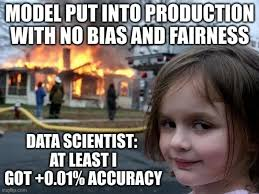

You receive three CSV files from a new collection of the same ACSIncome task:

- `week2_train_observed.csv`
- `week2_validation_observed.csv`
- `week2_test_features.csv`

You have received three new CSV files from a recent data collection effort for the ACSIncome task. However, this data was collected "in the wild" and has not been vetted. It may contain undocumented data-quality issues, distribution shifts, or inconsistent labels. 

You are **not** told whether a problem exists, what features are affected, or what caused the issues. Your task is to act and audit: you must explore the data, design robust checks to uncover issues, and critically interpret your findings to hypothesize what might be going wrong in the data pipeline. 

Do not jump directly to mitigation. A good audit strictly distinguishes between *observed evidence*, *hypotheses*, and *conclusions*.

In [2]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
#upgrade pip
%pip install --upgrade pip



Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency

RANDOM_STATE = 42
DATA_DIR = Path("/Users/sandrarune/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/9. sem/Ansvarlig AI/Fairness/Responsible_AI/data2")  # TODO: change if necessary

# In Colab you may instead upload the CSVs:
# from google.colab import files
# files.upload()

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
validation = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
test_features = pd.read_csv(DATA_DIR / "week2_test_features.csv")

print(train.shape, validation.shape, test_features.shape)
display(train.head())
print(train.info())

(18000, 15) (6000, 15) (6000, 14)


,row_id,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,SEX_group,RACE_group,SURVEY_BATCH,income_observed
0,0,23.0,1.0,20.0,5.0,9130.0,48.0,2.0,40.0,1.0,1.0,Male,White,B04,0
1,1,57.0,1.0,21.0,1.0,3255.0,301.0,1.0,35.0,2.0,1.0,Female,White,B06,1
2,2,29.0,1.0,21.0,1.0,6800.0,6.0,0.0,48.0,1.0,1.0,Male,White,B02,1
3,3,42.0,6.0,17.0,1.0,6200.0,313.0,1.0,40.0,1.0,1.0,Male,White,B04,0
4,4,67.0,1.0,20.0,1.0,3601.0,48.0,0.0,6.0,2.0,2.0,Female,Black,B08,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   row_id           18000 non-null  int64  
 1   AGEP             18000 non-null  float64
 2   COW              18000 non-null  float64
 3   SCHL             18000 non-null  float64
 4   MAR              18000 non-null  float64
 5   OCCP             18000 non-null  float64
 6   POBP             18000 non-null  float64
 7   RELP             18000 non-null  float64
 8   WKHP             18000 non-null  float64
 9   SEX              18000 non-null  float64
 10  RAC1P            18000 non-null  float64
 11  SEX_group        18000 non-null  object 
 12  RACE_group       18000 non-null  object 
 13  SURVEY_BATCH     18000 non-null  object 
 14  income_observed  18000 non-null  int64  
dtypes: float64(10), int64(2), object(3)
memory usage: 2.1+ MB
None


In [5]:
pd.crosstab(train["SEX_group"], train["income_observed"], normalize="index").rename(
    columns={0: "income<=50k", 1: "income>50k"}
)

income_observed,income<=50k,income>50k
SEX_group,,
Female,0.776645,0.223355
Male,0.574386,0.425614


Hints: Design checks for schema, missingness, duplicates, impossible values, group sizes, target prevalence, and feature drift. Do not assume a column is safe merely because its name sounds administrative.

Target prevalence

Det betyder simpelthen: hvor stor en andel af observationerne har Y=1 (den positive klasse) i jeres data. I jeres tilfælde er target income_observed, så target prevalence er fx "hvor mange procent af personerne har income_observed = 1?"

Feature drift

Det betyder: om fordelingen af en variabel (feature) ændrer sig mellem datasæt – typisk mellem jeres train, validation og test set, men konceptet bruges også generelt om, at data ændrer sig over tid (fx mellem forskellige SURVEY_BATCH-perioder).

In [6]:
# Check that the test features have the same columns as the training data (except for the target variable)
assert set(test_features.columns) == set(train.columns) - {"income_observed"}


In [7]:
# TODO: implement a reusable dataset summary.
def dataset_summary(df, label=None, name=""):
    #print shape 
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    
    # Schema - print column names and dtypes
    print(f"\nColumns:\n{df.columns.tolist()}")
    print(f"\nDtypes:\n{df.dtypes}")
    
    # Duplicates
    n_dup = df.duplicated().sum()
    print(f"\nFull-row duplicates: {n_dup}")
    if "row_id" in df.columns:
        n_dup_no_id = df.drop(columns="row_id").duplicated().sum()
        print(f"Duplicates excluding row_id: {n_dup_no_id}")
    
    # Missingness only NA values
    print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    
    # Impossible values for known numeric columns (cannot be negative or exceed reasonable limits)
    if "AGEP" in df.columns: # age cannot be negative or exceed 120
        print(f"\nAGEP range: {df['AGEP'].min()} - {df['AGEP'].max()}")
    if "WKHP" in df.columns: # work hours per week cannot be negative or exceed 168
        print(f"WKHP range: {df['WKHP'].min()} - {df['WKHP'].max()}")
    
    # Group sizes
    for group_col in ["SEX_group", "RACE_group", "SURVEY_BATCH"]:
        if group_col in df.columns:
            print(f"\n{group_col} counts:\n{df[group_col].value_counts()}")
    
    # Label distribution, overall and by group
    if label and label in df.columns:
        print(f"\nOverall {label} prevalence:\n{df[label].value_counts(normalize=True)}")
        for group_col in ["SEX_group", "RACE_group"]: #check specific sensitive groups for label prevalence
            if group_col in df.columns:
                print(f"\n{label} prevalence by {group_col}:")
                print(df.groupby(group_col)[label].mean())


# Check for any specific extreme or frequent values in numeric columns - which is not defined but not NA value
def flag_extreme_or_frequent_values(df, top_n=3):
    for col in df.select_dtypes(include=np.number).columns:
        print(f"\n{col}: min={df[col].min()}, max={df[col].max()}")
        top_vals = df[col].value_counts().head(top_n)
        print(f"Most common values:\n{top_vals}")

# TODO: compare train, validation, and test feature distributions.
def compare_distributions(df1, df2, name1="train", name2="validation"):
    numeric_cols = df1.select_dtypes(include=np.number).columns
    categorical_cols = df1.select_dtypes(exclude=np.number).columns
    
    print(f"--- Numeric drift ({name1} vs {name2}) ---")
    for col in numeric_cols:
        if col in df2.columns and col != "row_id":
            stat, p = ks_2samp(df1[col].dropna(), df2[col].dropna())
            flag = " <-- possible drift" if p < 0.01 else ""
            print(f"{col}: KS stat={stat:.3f}, p={p:.4f}{flag}")
    
    print(f"\n--- Categorical drift ({name1} vs {name2}) ---")
    for col in categorical_cols:
        if col in df2.columns:
            t1 = df1[col].value_counts(normalize=True)
            t2 = df2[col].value_counts(normalize=True)
            combined = pd.concat([t1, t2], axis=1, keys=[name1, name2]).fillna(0)
            print(f"\n{col}:\n{combined}")
            
# use functions to summarize datasets
dataset_summary(train, label="income_observed", name="Train")
dataset_summary(validation, label="income_observed", name="Validation")
dataset_summary(test_features, label=None, name="Test")  # no label present
flag_extreme_or_frequent_values(train)
flag_extreme_or_frequent_values(validation)
flag_extreme_or_frequent_values(test_features)
compare_distributions(train, validation, name1="train", name2="validation")
compare_distributions(train, test_features, name1="train", name2="test")



=== Train ===
Shape: (18000, 15)

Columns:
['row_id', 'AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P', 'SEX_group', 'RACE_group', 'SURVEY_BATCH', 'income_observed']

Dtypes:
row_id               int64
AGEP               float64
COW                float64
SCHL               float64
MAR                float64
OCCP               float64
POBP               float64
RELP               float64
WKHP               float64
SEX                float64
RAC1P              float64
SEX_group           object
RACE_group          object
SURVEY_BATCH        object
income_observed      int64
dtype: object

Full-row duplicates: 0
Duplicates excluding row_id: 12

Missing values:
Series([], dtype: int64)

AGEP range: 17.0 - 92.0
WKHP range: 1.0 - 99.0

SEX_group counts:
SEX_group
Male      9565
Female    8435
Name: count, dtype: int64

RACE_group counts:
RACE_group
White                   14021
Black                    1644
Asian                     924
Other race                

Train vs test

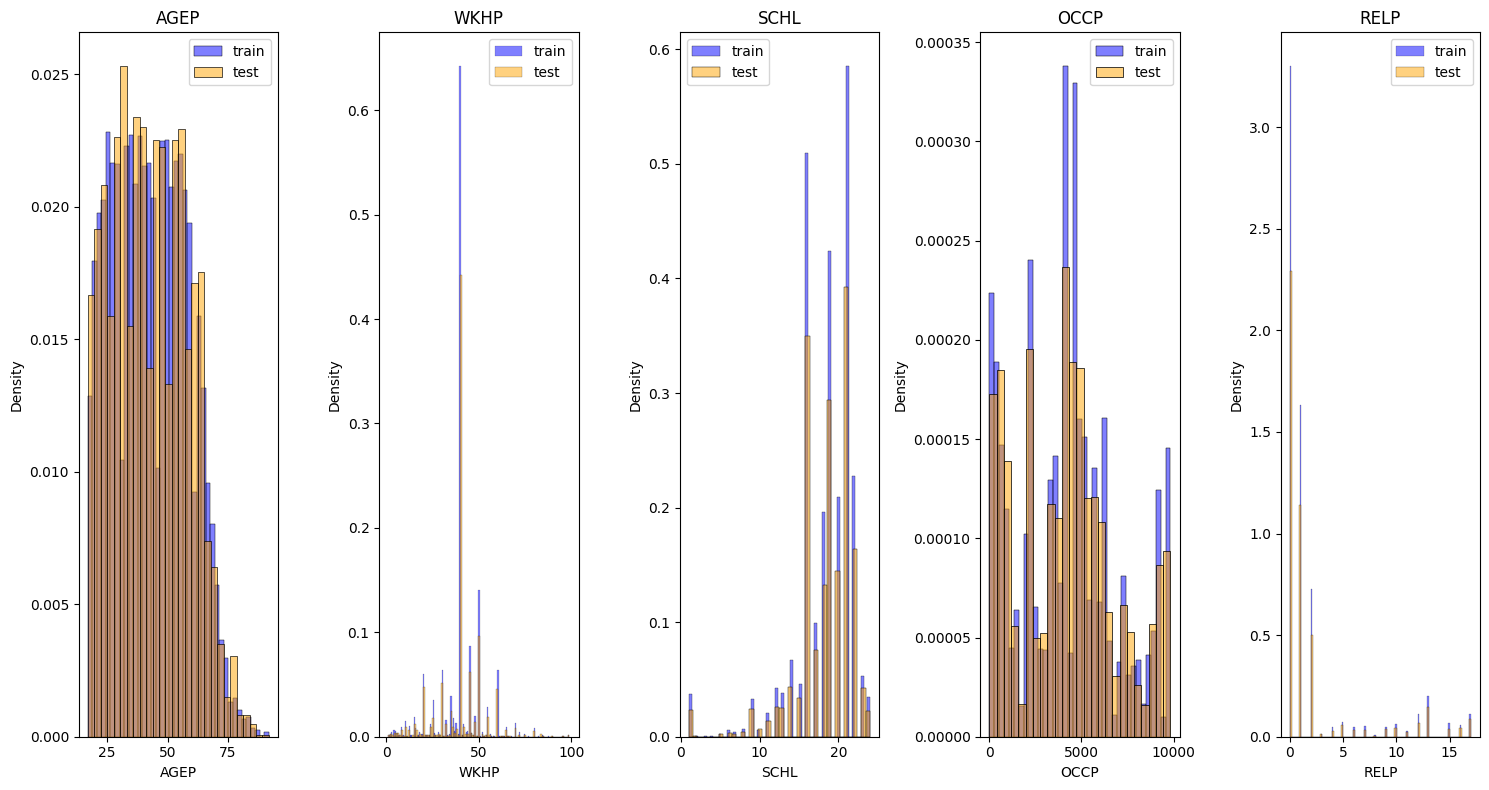

In [8]:
numeric_cols = ["AGEP", "WKHP", "SCHL", "OCCP", "RELP"]
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 8))

for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(train[col], color="blue", label="train", stat="density", 
                 kde=False, alpha=0.5, ax=ax)
    sns.histplot(test_features[col], color="orange", label="test", stat="density", 
                 kde=False, alpha=0.5, ax=ax)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

Target prevalence by group – bar chart

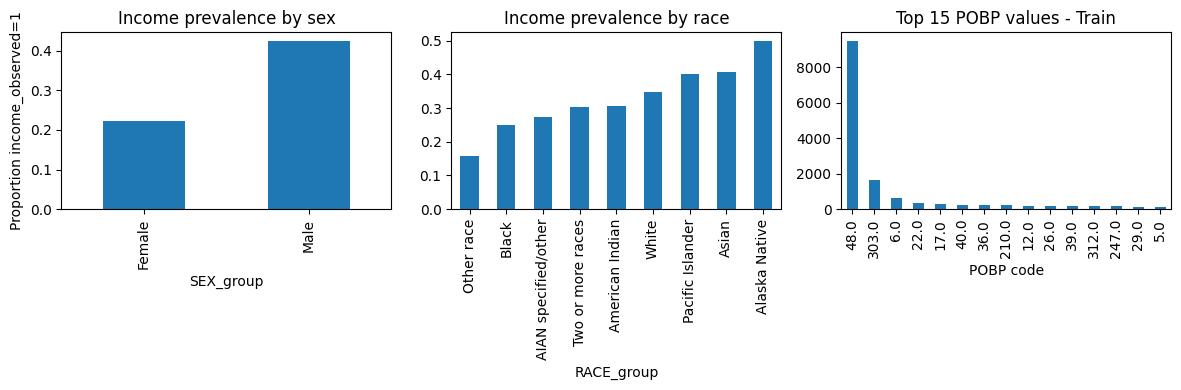

In [9]:
fig, axes = plt.subplots(1,3, figsize=(12, 4))
top_pobp = train["POBP"].value_counts().head(15)
top_pobp.plot(kind="bar", ax=axes[2])
axes[2].set_title("Top 15 POBP values - Train")
axes[2].set_xlabel("POBP code")

train.groupby("SEX_group")["income_observed"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Income prevalence by sex")
axes[0].set_ylabel("Proportion income_observed=1")

train.groupby("RACE_group")["income_observed"].mean().sort_values().plot(kind="bar", ax=axes[1])
axes[1].set_title("Income prevalence by race")
plt.tight_layout()
plt.show()

group sizes 

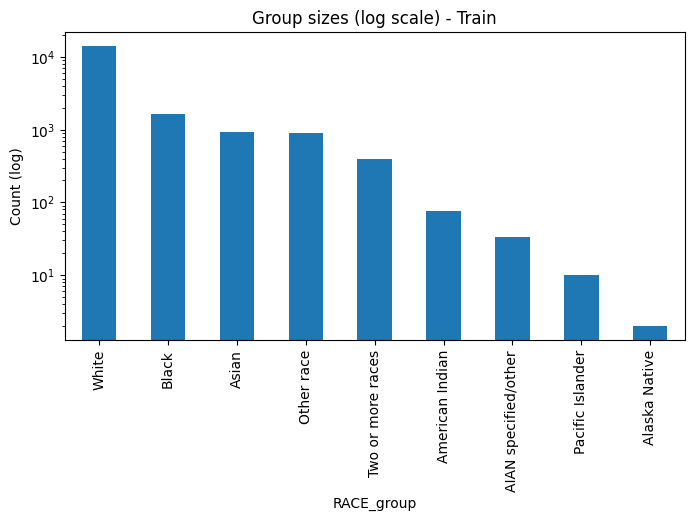

In [10]:
train["RACE_group"].value_counts().plot(kind="bar", logy=True, figsize=(8,4))
plt.title("Group sizes (log scale) - Train")
plt.ylabel("Count (log)")
plt.show()

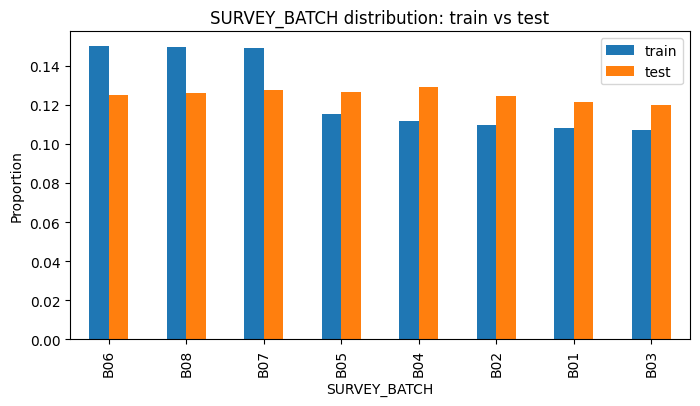

In [11]:
batch_compare = pd.concat([
    train["SURVEY_BATCH"].value_counts(normalize=True).rename("train"),
    test_features["SURVEY_BATCH"].value_counts(normalize=True).rename("test")
], axis=1)
batch_compare.plot(kind="bar", figsize=(8,4))
plt.title("SURVEY_BATCH distribution: train vs test")
plt.ylabel("Proportion")
plt.show()

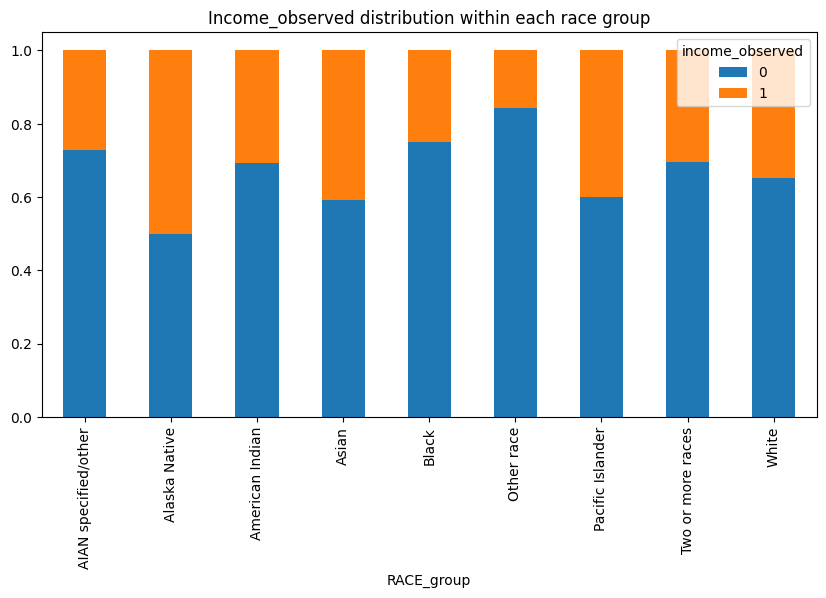

In [12]:
pd.crosstab(train["RACE_group"], train["income_observed"], normalize="index").plot(
    kind="bar", stacked=True, figsize=(10,5))
plt.title("Income_observed distribution within each race group")
plt.legend(title="income_observed")
plt.show()

Hints: Build at least two models, including a simple interpretable baseline. Decide which features belong in the model. Keep `row_id` out of the predictive feature set. Keep sensitive attributes available for auditing even if you exclude them from prediction.

Ekskluder:

row_id – ren identifikator, ingen prædiktiv information (og allerede nævnt eksplicit i hintet)
income_observed – det er target
SEX_group, RACE_group – de sensitive attributter. Hintet siger eksplicit: behold dem tilgængelige til audit, men ekskluder dem fra selve prædiktionen. I skal altså bruge dem bagefter til fairness-analysen, ikke som input til modellen
Overvej at ekskludere SEX og RAC1P også – det er jo bare de numerisk kodede versioner af de samme sensitive grupper! At fjerne SEX_group men beholde SEX (som er 1.0/2.0-kodning af samme ting) er reelt ingen forskel – I lækker stadig kønsinformation direkte ind i modellen. Det samme gælder RAC1P vs. RACE_group.
Overvej SURVEY_BATCH – I fandt selv, at den har anderledes fordeling i test end i train. Hvis I inkluderer den som feature, risikerer modellen at lære noget om tidsperiode i stedet for reelle prædiktorer, hvilket kan skade generaliserbarhed til test. Værd at diskutere eksplicit i jeres justering, i stedet for bare at inkludere/ekskludere den stiltiende.

Behold: AGEP, COW, SCHL, MAR, OCCP, POBP, RELP, WKHP – disse er direkte relateret til arbejde/uddannelse/husstand, som giver mening som prædiktorer for indkomst.

2. Numerisk vs. kategorisk – det vigtigste tekniske punkt

Fra jeres EDA ved I, at COW, SCHL, MAR, RELP er kodede kategorier, ikke kontinuerte tal, selvom de er gemt som float64. Hvis I fodrer dem direkte som numeriske ind i StandardScaler, antager modellen fejlagtigt at fx MAR=4 er "mere" end MAR=2 på en meningsfuld skala – det er forkert for kategoriske koder.

Kun AGEP og WKHP er reelt kontinuerte og bør skaleres numerisk. OCCP og POBP har for mange unikke værdier til ren one-hot (ville give enormt mange kolonner) – dem kunne I overveje target-encoding eller blot behandle som numeriske proxies for nu (med en kommentar om begrænsningen), afhængig af hvor avanceret jeres kursus forventer det.

simple baseline (Logistic Regressor)

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, brier_score_loss

LABEL = "income_observed"
ID = "row_id"
SENSITIVE = "SEX_group"

FEATURE_COLUMNS = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP"]

NUMERIC_FEATURES = ["AGEP", "WKHP"]
CATEGORICAL_FEATURES = ["COW", "SCHL", "MAR", "RELP"]
HIGH_CARDINALITY = ["OCCP", "POBP"]  # overvej separat behandling, eller inkluder i categorical med håndtering af unseen categories

# TODO: write a model factory that handles numeric and categorical columns.

# a simple model factory that creates a pipeline with preprocessing and logistic regression
def make_model(frame):
    numeric = ["AGEP", "WKHP"]
    categorical = ["COW", "SCHL", "MAR", "RELP", "OCCP", "POBP"]
    
    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ])
    
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])
    return model

# TODO: fit a baseline on observed training labels and evaluate against observed validation labels.
X_train = train[FEATURE_COLUMNS]
y_train = train[LABEL]
X_val = validation[FEATURE_COLUMNS]
y_val = validation[LABEL]

baseline = make_model(train)
baseline.fit(X_train, y_train)

val_pred = baseline.predict(X_val)
val_proba = baseline.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, val_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, val_pred))
print("ROC AUC:", roc_auc_score(y_val, val_proba))
print("Log loss:", log_loss(y_val, val_proba))
print("Brier score:", brier_score_loss(y_val, val_proba))

Accuracy: 0.7803333333333333
Balanced accuracy: 0.7387284815558333
ROC AUC: 0.849557049931827
Log loss: 0.44634484010614833
Brier score: 0.1460048977137162


Random Forest model

In [14]:
from sklearn.ensemble import RandomForestClassifier

def make_rf_model(frame):
    numeric = ["AGEP", "WKHP"]
    categorical = ["COW", "SCHL", "MAR", "RELP", "OCCP", "POBP"]
    
    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ])
    
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300, 
            max_depth=None,  # lad træerne vokse frit
            min_samples_leaf=5,  # men undgå overfitting via leaf-size i stedet
            class_weight="balanced",  # kompenser for skæv fordeling
            random_state=RANDOM_STATE
        ))
    ])
    return model

rf_model = make_rf_model(train)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)
rf_proba = rf_model.predict_proba(X_val)[:, 1]

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_val, rf_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, rf_pred))
print("ROC AUC:", roc_auc_score(y_val, rf_proba))
print("Log loss:", log_loss(y_val, rf_proba))
print("Brier score:", brier_score_loss(y_val, rf_proba))

=== Random Forest ===
Accuracy: 0.7501666666666666
Balanced accuracy: 0.7591198612475043
ROC AUC: 0.8351530286456604
Log loss: 0.5209422926589392
Brier score: 0.17315044976772376


Compute overall and group-specific utility, selection rate, TPR, FPR, PPV, NPV, equalized-odds components, and probability metrics. Report counts and uncertainty. Explicitly label every result as being evaluated against $Y^{obs}$.

In [15]:
from fairlearn.metrics import MetricFrame, selection_rate, count, equalized_odds_difference
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

# precision score = PPV and recall = TPR

def true_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else np.nan

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

def positive_predictive_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tp / (tp + fp) if (tp + fp) > 0 else np.nan

def negative_predictive_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan

metrics = {
    "selection_rate": selection_rate,
    "count": count,
    "TPR": true_positive_rate,
    "FPR": false_positive_rate,
    "PPV": positive_predictive_value,
    "NPV": negative_predictive_value,
    "accuracy": accuracy_score,
}

# --- Predictions (genberegnes her for at sikre de findes uanset cellerækkefølge) ---
X_val = validation[FEATURE_COLUMNS]
y_val = validation[LABEL]

lr_pred = baseline.predict(X_val)
rf_pred = rf_model.predict(X_val)

# --- MetricFrame by SEX_group ---
mf_lr_sex = MetricFrame(
    metrics=metrics,
    y_true=y_val,
    y_pred=lr_pred,
    sensitive_features=validation["SEX_group"]
)
print("=== Logistic Regression by SEX_group (evaluated against Y_obs) ===")
print(mf_lr_sex.by_group)

mf_rf_sex = MetricFrame(
    metrics=metrics,
    y_true=y_val,
    y_pred=rf_pred,
    sensitive_features=validation["SEX_group"]
)
print("\n=== Random Forest by SEX_group (evaluated against Y_obs) ===")
print(mf_rf_sex.by_group)

# --- Equalized odds difference (separat, ikke i MetricFrame) ---
eo_diff_lr = equalized_odds_difference(y_val, lr_pred, sensitive_features=validation["SEX_group"])
eo_diff_rf = equalized_odds_difference(y_val, rf_pred, sensitive_features=validation["SEX_group"])

print(f"\nEqualized odds difference (LR, SEX_group): {eo_diff_lr:.4f}")
print(f"Equalized odds difference (RF, SEX_group): {eo_diff_rf:.4f}")

# --- Intersection: SEX_group x RACE_group ---
intersection = validation["SEX_group"] + " / " + validation["RACE_group"]

mf_lr_intersect = MetricFrame(
    metrics=metrics,
    y_true=y_val,
    y_pred=lr_pred,
    sensitive_features=intersection
)
print("\n=== Logistic Regression by SEX x RACE (evaluated against Y_obs) ===")
print(mf_lr_intersect.by_group)

mf_rf_intersect = MetricFrame(
    metrics=metrics,
    y_true=y_val,
    y_pred=rf_pred,
    sensitive_features=intersection
)
print("\n=== Random Forest by SEX x RACE (evaluated against Y_obs) ===")
print(mf_rf_intersect.by_group)

eo_diff_lr_intersect = equalized_odds_difference(y_val, lr_pred, sensitive_features=intersection)
eo_diff_rf_intersect = equalized_odds_difference(y_val, rf_pred, sensitive_features=intersection)

print(f"\nEqualized odds difference (LR, SEX x RACE): {eo_diff_lr_intersect:.4f}")
print(f"Equalized odds difference (RF, SEX x RACE): {eo_diff_rf_intersect:.4f}")

=== Logistic Regression by SEX_group (evaluated against Y_obs) ===
           selection_rate   count       TPR       FPR       PPV       NPV  \
SEX_group                                                                   
Female           0.222617  2812.0  0.512821  0.139854  0.511182  0.860933   
Male             0.359473  3188.0  0.658466  0.130676  0.794066  0.768854   

           accuracy  
SEX_group            
Female     0.783073  
Male       0.777917  

=== Random Forest by SEX_group (evaluated against Y_obs) ===
           selection_rate   count       TPR       FPR       PPV       NPV  \
SEX_group                                                                   
Female           0.395448  2812.0  0.769231  0.288848  0.431655  0.915294   
Male             0.481493  3188.0  0.793777  0.242525  0.714658  0.827586   

           accuracy  
SEX_group            
Female     0.724040  
Male       0.773212  

Equalized odds difference (LR, SEX_group): 0.1456
Equalized odds difference 

In [16]:
# maximal discrepancy for LR
tpr_by_group = mf_lr_intersect.by_group["TPR"]
fpr_by_group = mf_lr_intersect.by_group["FPR"]

print("TPR spread:", tpr_by_group.max() - tpr_by_group.min())
print("Max TPR group:", tpr_by_group.idxmax(), tpr_by_group.max())
print("Min TPR group:", tpr_by_group.idxmin(), tpr_by_group.min())

print("\nFPR spread:", fpr_by_group.max() - fpr_by_group.min())
print("Max FPR group:", fpr_by_group.idxmax(), fpr_by_group.max())
print("Min FPR group:", fpr_by_group.idxmin(), fpr_by_group.min())

TPR spread: 1.0
Max TPR group: Female / AIAN specified/other 1.0
Min TPR group: Female / American Indian 0.0

FPR spread: 0.25
Max FPR group: Female / American Indian 0.25
Min FPR group: Female / AIAN specified/other 0.0


In [17]:
# maximal discrepancy for RF
tpr_by_group = mf_rf_intersect.by_group["TPR"]
fpr_by_group = mf_rf_intersect.by_group["FPR"]

print("TPR spread:", tpr_by_group.max() - tpr_by_group.min())
print("Max TPR group:", tpr_by_group.idxmax(), tpr_by_group.max())
print("Min TPR group:", tpr_by_group.idxmin(), tpr_by_group.min())

print("\nFPR spread:", fpr_by_group.max() - fpr_by_group.min())
print("Max FPR group:", fpr_by_group.idxmax(), fpr_by_group.max())
print("Min FPR group:", fpr_by_group.idxmin(), fpr_by_group.min())

TPR spread: 1.0
Max TPR group: Female / AIAN specified/other 1.0
Min TPR group: Female / American Indian 0.0

FPR spread: 0.625
Max FPR group: Male / American Indian 0.625
Min FPR group: Female / AIAN specified/other 0.0


Det er selve definitionen af equalized odds-metrikken: den tager den største forskel mellem nogen to grupper på enten TPR eller FPR, og rapporterer det ene tal. En værdi på præcis 1.000 betyder, at et sted i data er der to grupper, hvor den ene har TPR eller FPR = 0 og den anden har TPR eller FPR = 1 — altså den maksimalt mulige forskel overhovedet (skalaen går fra 0 = perfekt lige, til 1 = mest ulige muligt).

Konkret fra jeres tal: Male/Pacific Islander har TPR=NaN (kun 1 person, ingen sande positive at måle på), mens andre grupper har fx TPR eller FPR ved 0 eller 1 pga. meget få observationer — det er dette ekstrem-punkt, der driver equalized-odds-tallet helt op til 1.000, ikke en generel, gennemgående ulighed mellem fx mænd og kvinder som helhed.

Kort sagt til posteren: "Equalized odds difference = 1.000" lyder som "modellen er maksimalt uretfærdig", men betyder her reelt "mindst ét par af ekstremt små grupper har modsatte TPR/FPR-ekstremer" — hvilket er præcis jeres pointe om, at tallet er støj-drevet, ikke et reelt bevis på grov diskrimination.

In [18]:
# some groups can be very small in splits especially in intersections, therefore we add confidensintervals on selection 
def proportion_ci(p, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    se = np.sqrt(p * (1-p) / n)
    return (p - z*se, p + z*se)

def add_confidence_intervals(mf_by_group, metric_col="selection_rate"):
    results = []
    for group, row in mf_by_group.iterrows():
        p = row[metric_col]
        n = row["count"]
        ci_low, ci_high = proportion_ci(p, n)
        results.append({"group": group, metric_col: p, "n": n, "ci_low": ci_low, "ci_high": ci_high})
    return pd.DataFrame(results).set_index("group")

print("=== LR selection_rate with 95% CI, by SEX x RACE ===")
print(add_confidence_intervals(mf_lr_intersect.by_group, "selection_rate"))

=== LR selection_rate with 95% CI, by SEX x RACE ===
                               selection_rate       n    ci_low   ci_high
group                                                                    
Female / AIAN specified/other        0.166667     6.0 -0.131538  0.464871
Female / American Indian             0.222222     9.0 -0.049394  0.493839
Female / Asian                       0.333333   153.0  0.258636  0.408030
Female / Black                       0.150877   285.0  0.109321  0.192433
Female / Other race                  0.129310   116.0  0.068248  0.190373
Female / Pacific Islander            0.500000     2.0 -0.192965  1.192965
Female / Two or more races           0.200000    55.0  0.094285  0.305715
Female / White                       0.229643  2186.0  0.212011  0.247275
Male / AIAN specified/other          0.000000     9.0  0.000000  0.000000
Male / American Indian               0.181818    11.0 -0.046113  0.409749
Male / Asian                         0.484848   165.0  0.40

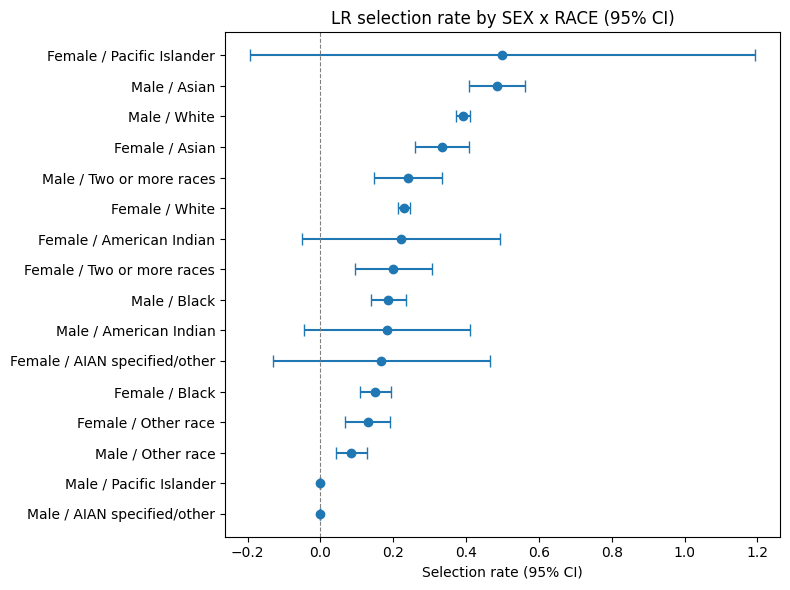

In [19]:
import matplotlib.pyplot as plt

def plot_selection_rate_ci(ci_df, title):
    ci_df = ci_df.sort_values("selection_rate")
    errors = [ci_df["selection_rate"] - ci_df["ci_low"], 
              ci_df["ci_high"] - ci_df["selection_rate"]]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar(ci_df["selection_rate"], range(len(ci_df)), 
                xerr=errors, fmt="o", capsize=4)
    ax.set_yticks(range(len(ci_df)))
    ax.set_yticklabels(ci_df.index)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Selection rate (95% CI)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

ci_lr = add_confidence_intervals(mf_lr_intersect.by_group, "selection_rate")
plot_selection_rate_ci(ci_lr, "LR selection rate by SEX x RACE (95% CI)")

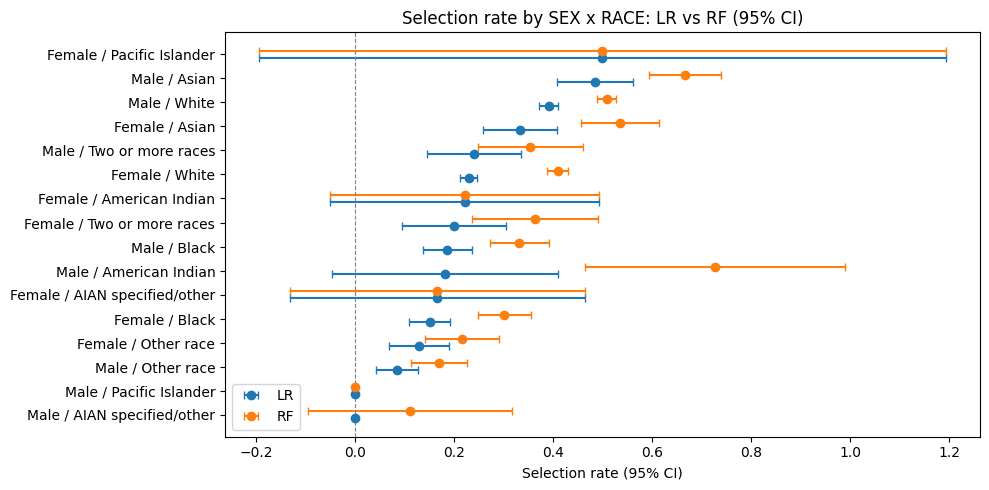

In [20]:
def plot_selection_rate_ci_comparison(ci_lr, ci_rf, title):
    ci_lr = ci_lr.sort_values("selection_rate")
    order = ci_lr.index  # brug samme rækkefølge for begge
    ci_rf = ci_rf.reindex(order)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    y_pos = np.arange(len(order))
    
    errors_lr = [ci_lr["selection_rate"] - ci_lr["ci_low"], ci_lr["ci_high"] - ci_lr["selection_rate"]]
    errors_rf = [ci_rf["selection_rate"] - ci_rf["ci_low"], ci_rf["ci_high"] - ci_rf["selection_rate"]]
    
    ax.errorbar(ci_lr["selection_rate"], y_pos - 0.15, xerr=errors_lr, fmt="o", capsize=3, label="LR", color="tab:blue")
    ax.errorbar(ci_rf["selection_rate"], y_pos + 0.15, xerr=errors_rf, fmt="o", capsize=3, label="RF", color="tab:orange")
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Selection rate (95% CI)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

ci_rf = add_confidence_intervals(mf_rf_intersect.by_group, "selection_rate")
plot_selection_rate_ci_comparison(ci_lr, ci_rf, "Selection rate by SEX x RACE: LR vs RF (95% CI)")

/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_1629/1926605944.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_with_n_pos)


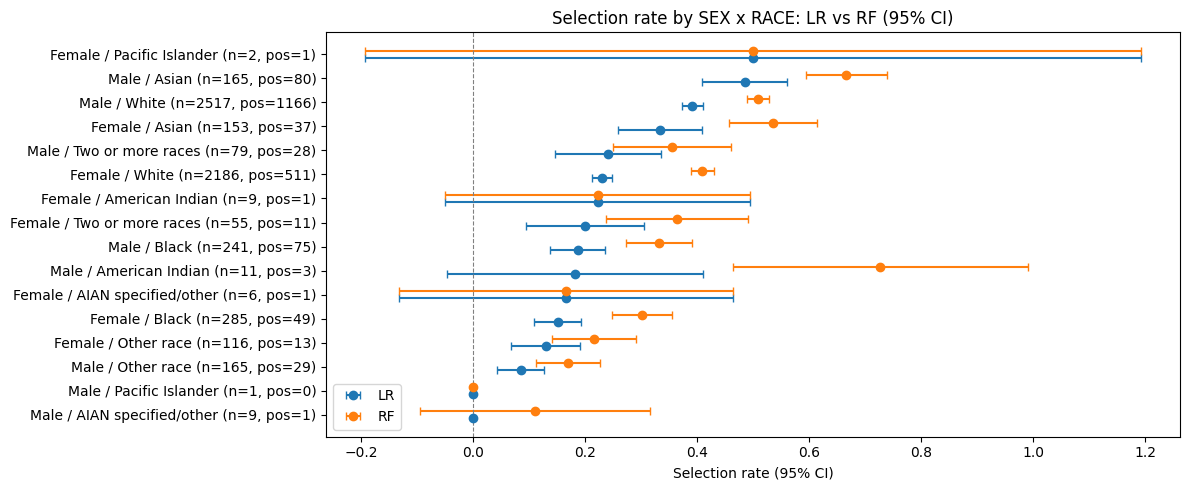

In [34]:
def plot_selection_rate_ci_comparison(ci_lr, ci_rf, title):
    ci_lr = ci_lr.sort_values("selection_rate")
    order = ci_lr.index
    ci_rf = ci_rf.reindex(order)
    
    # Byg labels med n inkluderet
    labels_with_n = [f"{g} (n={int(ci_lr.loc[g, 'n'])})" for g in order]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    y_pos = np.arange(len(order))
    
    errors_lr = [ci_lr["selection_rate"] - ci_lr["ci_low"], ci_lr["ci_high"] - ci_lr["selection_rate"]]
    errors_rf = [ci_rf["selection_rate"] - ci_rf["ci_low"], ci_rf["ci_high"] - ci_rf["selection_rate"]]
    
    ax.errorbar(ci_lr["selection_rate"], y_pos - 0.15, xerr=errors_lr, fmt="o", capsize=3, label="LR", color="tab:blue")
    ax.errorbar(ci_rf["selection_rate"], y_pos + 0.15, xerr=errors_rf, fmt="o", capsize=3, label="RF", color="tab:orange")
    # Beregn actual positives per intersection-gruppe
# Beregn actual positives per intersection-gruppe
    intersection = validation["SEX_group"] + " / " + validation["RACE_group"]
    positives_by_group = y_val.groupby(intersection).sum()

    ci_lr["positives"] = ci_lr.index.map(positives_by_group)

    labels_with_n_pos = [f"{g} (n={int(ci_lr.loc[g,'n'])}, pos={int(ci_lr.loc[g,'positives'])})" for g in order]
    ax.set_yticklabels(labels_with_n_pos)
    ax.set_yticks(y_pos)
 # <-- n er nu en del af label
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Selection rate (95% CI)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_selection_rate_ci_comparison(ci_lr, ci_rf, "Selection rate by SEX x RACE: LR vs RF (95% CI)")

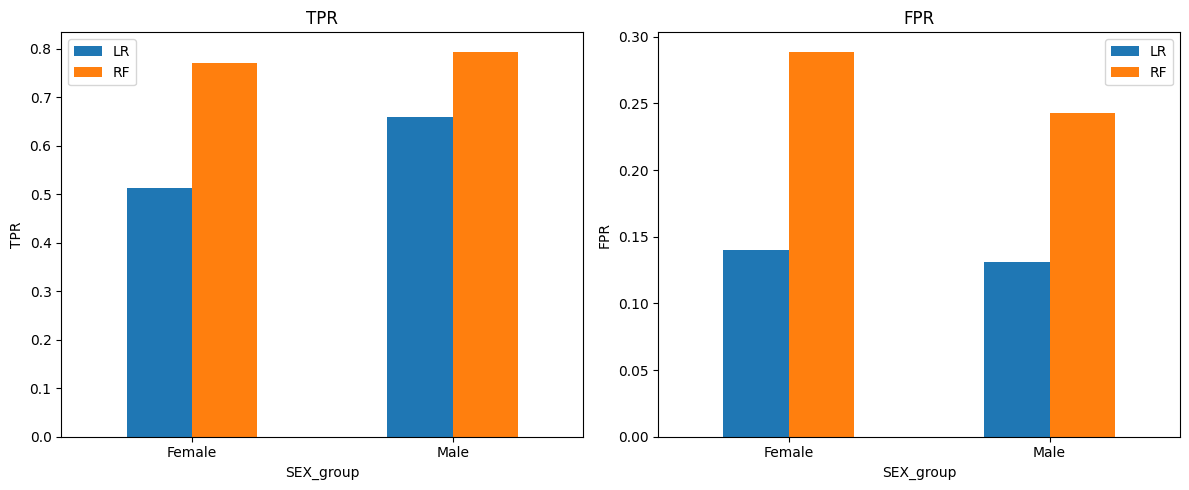

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics_to_plot = ["TPR", "FPR"]
for ax, metric in zip(axes, metrics_to_plot):
    df_plot = pd.DataFrame({
        "LR": mf_lr_sex.by_group[metric],
        "RF": mf_rf_sex.by_group[metric]
    })
    df_plot.plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

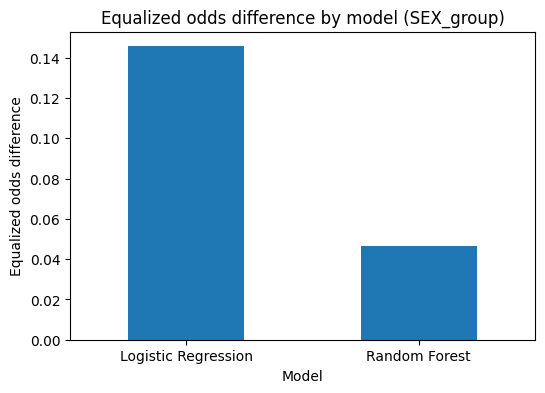

In [23]:
eo_data = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "SEX_group": [eo_diff_lr, eo_diff_rf],
})
eo_data.set_index("Model").plot(kind="bar", legend=False, figsize=(6,4))
plt.ylabel("Equalized odds difference")
plt.title("Equalized odds difference by model (SEX_group)")
plt.xticks(rotation=0)
plt.show()

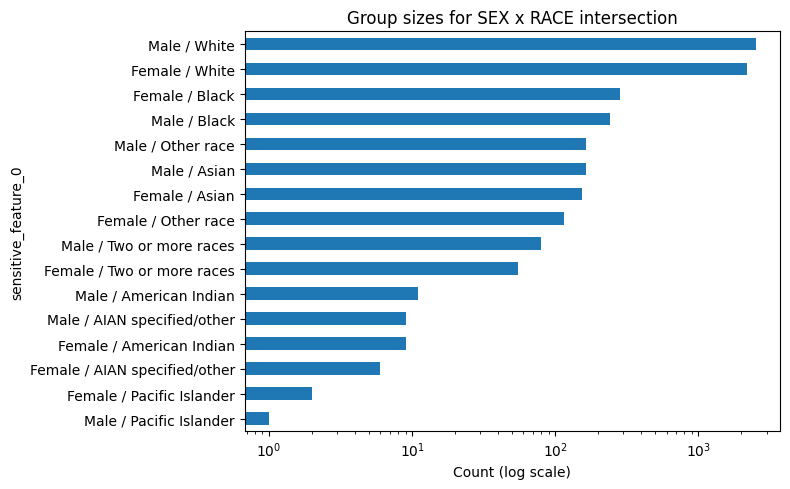

In [24]:
fig, ax = plt.subplots(figsize=(8,5))
mf_lr_intersect.by_group["count"].sort_values().plot(kind="barh", ax=ax, logx=True) # much more interpretable
ax.set_xlabel("Count (log scale)")
ax.set_title("Group sizes for SEX x RACE intersection")
plt.tight_layout()
plt.show()

In [25]:
mask = (validation["SEX_group"] == "Female") & (validation["RACE_group"] == "American Indian")
n = mask.sum()
tp = ((y_val == 1) & (lr_pred == 1) & mask).sum()
actual_positives = (y_val[mask] == 1).sum()

print(f"n = {n}")
print(f"Actual positives (income_observed=1) in this group = {actual_positives}")
print(f"True positives (correctly predicted) = {tp}")

n = 9
Actual positives (income_observed=1) in this group = 1
True positives (correctly predicted) = 0


In [26]:
mask = (validation["SEX_group"] == "Male") & (validation["RACE_group"] == "Pacific Islander")
n = mask.sum()
tp = ((y_val == 1) & (lr_pred == 1) & mask).sum()
actual_positives = (y_val[mask] == 1).sum()

print(f"n = {n}")
print(f"Actual positives (income_observed=1) in this group = {actual_positives}")
print(f"True positives (correctly predicted) = {tp}")

n = 1
Actual positives (income_observed=1) in this group = 0
True positives (correctly predicted) = 0


In [27]:
mask = (validation["SEX_group"] == "Female") & (validation["RACE_group"] == "Pacific Islander")
n = mask.sum()
tp = ((y_val == 1) & (lr_pred == 1) & mask).sum()
actual_positives = (y_val[mask] == 1).sum()

print(f"n = {n}")
print(f"Actual positives (income_observed=1) in this group = {actual_positives}")
print(f"True positives (correctly predicted) = {tp}")

n = 2
Actual positives (income_observed=1) in this group = 1
True positives (correctly predicted) = 1


In [28]:
def group_tp_summary(sex, race):
    mask = (validation["SEX_group"] == sex) & (validation["RACE_group"] == race)
    n = mask.sum()
    actual_positives = (y_val[mask] == 1).sum()
    tp = ((y_val == 1) & (lr_pred == 1) & mask).sum()
    return {"Group": f"{sex}/{race}", "n": n, "Actual positives": actual_positives, "TP": tp}

groups_to_check = [
    ("Female", "American Indian"),
    ("Male", "Pacific Islander"),
    ("Female", "Pacific Islander"),
]

summary = pd.DataFrame([group_tp_summary(sex, race) for sex, race in groups_to_check])
print(summary.to_string(index=False))

                  Group  n  Actual positives  TP
 Female/American Indian  9                 1   0
  Male/Pacific Islander  1                 0   0
Female/Pacific Islander  2                 1   1


### Mitigating observed bias

Hint: The Threshold Optimizer method in FairLearn (https://fairlearn.org/v0.5.0/api_reference/fairlearn.postprocessing.html) can be used to enforce e.g. the Equalized Odds criterion -- we have learned about how it works in week 2. But for now, apply the Threshold_Optimizer to mitigate bias according to one of your chosen criteria (using the "constraints" option). Repeat your fairness diagnostics for the updated model. Did the mitigation make the model more fair in all respects?

Calibration must name its target label. Compare group reliability curves and Brier scores against `income_observed`. Inspect whether apparent calibration differs by group and by score range.

Any more mitigation stratergies you could think of? Do they work on the observed data? 

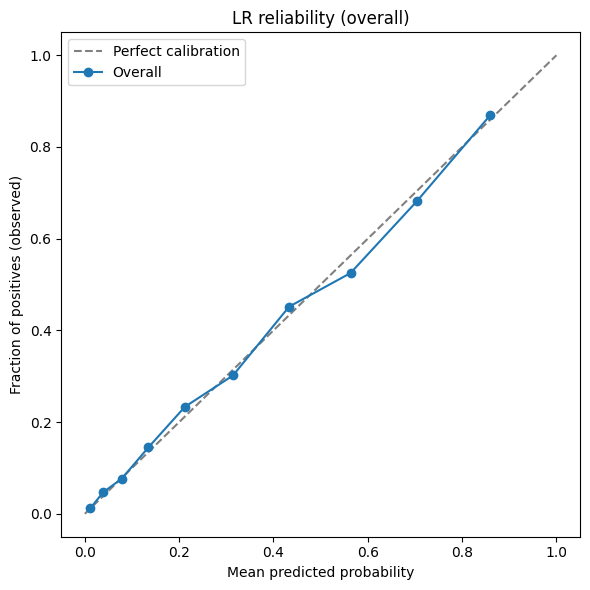

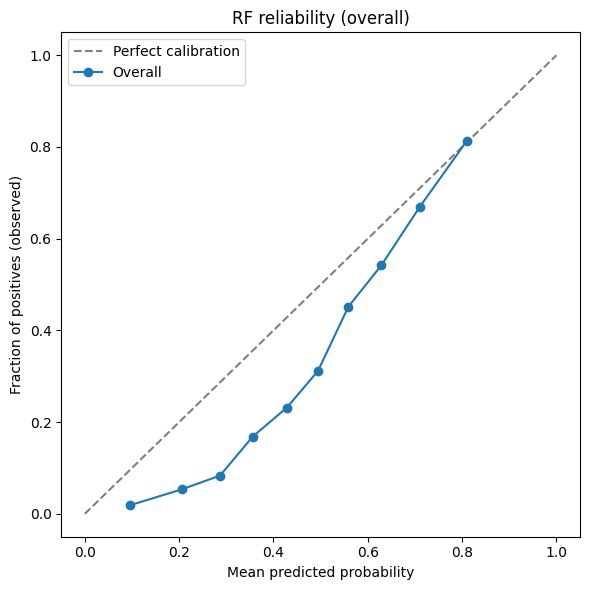

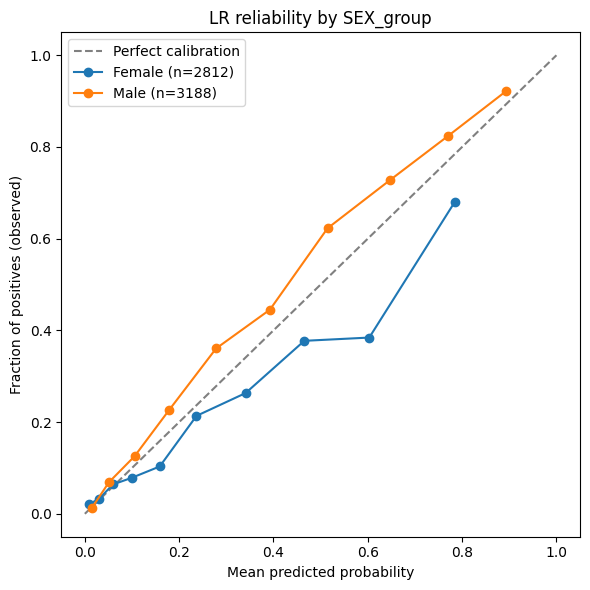

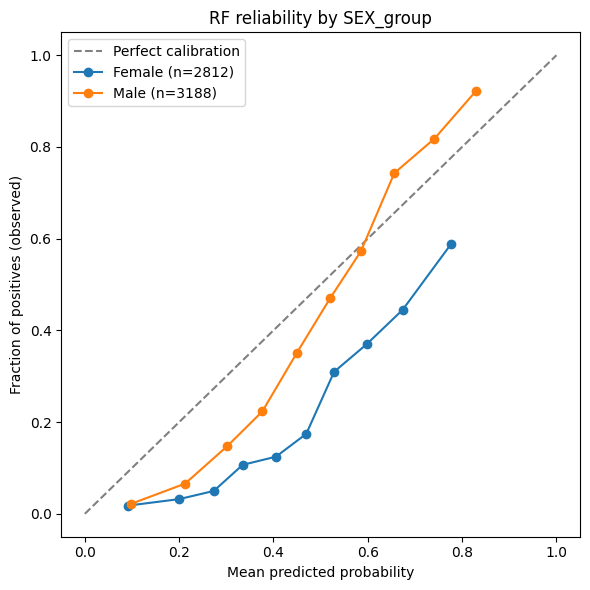

ECE (Logistic Regression): 0.014
ECE (Random Forest): 0.124
Female: ECE(LR)=0.0607, ECE(RF)=0.2132
Male: ECE(LR)=0.0493, ECE(RF)=0.0949
   mean_predicted  observed_fraction       gap    n
0        0.011256           0.011667  0.000410  600
1        0.038578           0.046667  0.008089  600
2        0.078249           0.076667 -0.001582  600
3        0.134882           0.145000  0.010118  600
4        0.212203           0.233333  0.021131  600
5        0.314092           0.301667 -0.012425  600
6        0.433099           0.451667  0.018568  600
7        0.563341           0.525000 -0.038341  600
8        0.704043           0.681667 -0.022377  600
9        0.860198           0.870000  0.009802  600


In [29]:
# TODO: implement calibration tables, reliability plots, and a numerical summary such as ECE.
# State how you handle small bins and why your binning choice is defensible.

# Reliability plot
from sklearn.calibration import calibration_curve

def reliability_data(y_true, y_proba, n_bins=10, strategy="quantile"):
    """
    strategy='quantile': lige mange observationer per bin (bedre til skæve fordelinger)
    strategy='uniform': lige brede bins (0-0.1, 0.1-0.2, osv.)
    """
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins, strategy=strategy)
    return prob_true, prob_pred

# reliability overall per group
def plot_reliability(y_true, y_proba, group=None, n_bins=10, title=""):
    fig, ax = plt.subplots(figsize=(6,6))
    ax.plot([0,1], [0,1], linestyle="--", color="gray", label="Perfect calibration")
    
    if group is None:
        prob_true, prob_pred = reliability_data(y_true, y_proba, n_bins=n_bins)
        ax.plot(prob_pred, prob_true, marker="o", label="Overall")
    else:
        for g in group.unique():
            mask = (group == g)
            n = mask.sum()
            bins = min(n_bins, max(2, n // 30))  # reducer bins hvis gruppen er lille
            try:
                prob_true, prob_pred = reliability_data(y_true[mask], y_proba[mask], n_bins=bins)
                ax.plot(prob_pred, prob_true, marker="o", label=f"{g} (n={n})")
            except Exception as e:
                print(f"Skipping group {g} (n={n}): {e}")
    
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives (observed)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

lr_proba_val = baseline.predict_proba(X_val)[:, 1]
rf_proba_val = rf_model.predict_proba(X_val)[:, 1]

plot_reliability(y_val, lr_proba_val, group=None, title="LR reliability (overall)")
plot_reliability(y_val, rf_proba_val, group=None, title="RF reliability (overall)")

plot_reliability(y_val, lr_proba_val, group=validation["SEX_group"], title="LR reliability by SEX_group")
plot_reliability(y_val, rf_proba_val, group=validation["SEX_group"], title="RF reliability by SEX_group")
# TODO: Mitigation

# Expected calibration error
def expected_calibration_error(y_true, y_proba, n_bins=10, strategy="quantile"):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    
    if strategy == "quantile":
        bin_edges = np.quantile(y_proba, np.linspace(0, 1, n_bins + 1))
        bin_edges[-1] += 1e-8  # sikr sidste punkt inkluderes
    else:
        bin_edges = np.linspace(0, 1, n_bins + 1)
    
    ece = 0.0
    n = len(y_true)
    for i in range(n_bins):
        mask = (y_proba >= bin_edges[i]) & (y_proba < bin_edges[i+1])
        bin_n = mask.sum()
        if bin_n == 0:
            continue
        bin_acc = y_true[mask].mean()
        bin_conf = y_proba[mask].mean()
        ece += (bin_n / n) * abs(bin_acc - bin_conf)
    return ece

ece_lr = expected_calibration_error(y_val, lr_proba_val)
ece_rf = expected_calibration_error(y_val, rf_proba_val)

print(f"ECE (Logistic Regression): {ece_lr:.3f}")
print(f"ECE (Random Forest): {ece_rf:.3f}")

# ECE per gruppe
for g in validation["SEX_group"].unique():
    mask = validation["SEX_group"] == g
    ece_g_lr = expected_calibration_error(y_val[mask].values, lr_proba_val[mask])
    ece_g_rf = expected_calibration_error(y_val[mask].values, rf_proba_val[mask])
    print(f"{g}: ECE(LR)={ece_g_lr:.4f}, ECE(RF)={ece_g_rf:.4f}")
    
# Calibration tabel
def calibration_table(y_true, y_proba, n_bins=10):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins, strategy="quantile")
    
    # Beregn antal observationer per bin manuelt (matcher calibration_curve's quantile-bins)
    bin_edges = np.quantile(y_proba, np.linspace(0, 1, n_bins + 1))
    bin_edges[-1] += 1e-8
    counts = []
    for i in range(len(bin_edges) - 1):
        mask = (y_proba >= bin_edges[i]) & (y_proba < bin_edges[i+1])
        counts.append(mask.sum())
    
    return pd.DataFrame({
        "mean_predicted": prob_pred,
        "observed_fraction": prob_true,
        "gap": prob_true - prob_pred,
        "n": counts[:len(prob_pred)]  # calibration_curve kan slå tomme bins sammen, så vi matcher længden
    })

print(calibration_table(y_val, lr_proba_val))

## Week 2 : What to think about?

1. Audit plan and model cards for your baselines.
2. Observed-label performance, fairness, and calibration.
3. Label-quality evidence ?
4. Instability evidence?
5. Two competing explanations for your findings.
7. A clear separation between **observed evidence**, **hypothesis**, and **conclusion**.

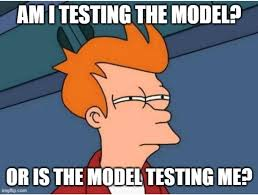

## 📝 Project 1 Submission Guidelines (Week 2 Contribution)

The investigations and hypotheses generated from this Week 2 notebook will form the second major section of your final A0 poster (~ another 1/3 of the poster).

When preparing your poster, ensure this section includes:
* Briefly outline the models and checks you used to establish performance and fairness baselines on the observed (but untrusted (?)) labels.
* *Highlight the most compelling evidence of data labels issue or generalizability issues you discovered (e.g., highly suspicious/unstable features, strange sub-group performances, or findings using popular frameworks).
* Present your strongest hypotheses explaining *why* these anomalies exist in the data. Clearly separate your observed data evidence from your conclusions about what real-world issues (such as systemic biases or collection flaws) might be causing them.


Hypothesis explanation

H1:Y_obs er formentlig differentielt korrumperet/undersamplet i forhold til den sande label, og rammer kvinder hårdere

Hvorfor I tror det (evidensen):

Vi fandt, at det oprindelige, fulde datasæt (50.000 personer, baseret på den rå PINCP-værdi thresholdet ved $50k) havde 34.9% af kvinder og 46.6% af mænd over grænsen
Den split-kode, Vi fandt (stratificeret på y_reference), viste at en korrekt/afbalanceret opdeling i train/val/test bevarer denne rate (~41% samlet, konstant kønsfordeling) på tværs af alle splits
Men jeres faktiske trænings-data (income_observed) viser kun 22.3% positive for kvinder, et fald på 12.6 procentpoint, mens mænd kun falder 4 procentpoint (46.6%→42.6%)

Konklusionen I drager: Noget er sket mellem den rene reference-label og den income_observed, I fik udleveret og det noget rammer kvinder markant hårdere. Det kunne være: fejlagtig nedjustering af nogle kvinders indkomst i datapipelinen, systematisk udeladelse af høj-indkomst-kvinder fra "observed"-datasættet, eller en anden form for label-støj indført bevidst til øvelsen (kurset har jo eksplicit sagt, at Y_obs may be corrupted

Hvorfor det er vigtigt: Hvis denne hypotese er sand, betyder det, at de fairness-problemer, I ser (kalibreringsgab, TPR/FPR-forskelle), måske ikke skyldes, at jeres model (LR/RF) er dårlig eller partisk – de kan i stedet skyldes, at modellen er trænet på i forvejen skæve labels. En perfekt model trænet på skæve labels vil stadig give skæve resultater.

Hvorfor det stadig kun er en hypotese: I har ikke selve income_reference-filen endnu (den kommer først i Week 3) – så I kan ikke direkte bekræfte, om income_observed faktisk afviger fra income_reference for netop de rows, I har. I har kun indirekte evidens via sammenligning med det oprindelige, ukorrumperede datasæt fra Week 1.

H2: Equalized-odds ≈1.0 ved intersektion afspejler støj fra små stikprøver, ikke nødvendigvis reel bias

Hvad det betyder: Det ekstreme tal, I fandt (equalized odds difference = 1.000, den maksimalt mulige værdi), skyldes formentlig ikke, at modellen er grusomt uretfærdig mod bestemte køn×race-kombinationer – det skyldes, at nogle af disse grupper er så små (n=1, n=2, n=9), at selv én forkert forudsigelse giver et vildt udslag i TPR/FPR.

Hvorfor I tror det (evidensen):

Grupper som "Male/Pacific Islander" har kun 1 person i valideringssættet
"Male/AIAN specified/other" har kun 9 personer
Jeres CI-plot viser, at konfidensintervallerne for disse grupper er enorme (fx -0.19 til 1.19 for en gruppe med n=2) – bogstaveligt talt bredere end det muligt interval [0,1]
I modsætning hertil har store grupper (White, n>2000) meget smalle, pålidelige intervaller

Konklusionen I drager: Et enkelt ekstremt datapunkt (fx én person, som modellen tilfældigvis forudsagde forkert) kan alene drive hele equalized-odds-metrikken op til dens maksimale værdi. Det er statistisk støj, ikke et pålideligt tegn på systematisk diskrimination mod disse specifikke grupper.

Hvorfor det er vigtigt: Det advarer mod at fejltolke et højt equalized-odds-tal som bevis på grov bias, når det reelt bare afspejler, at datasættet ikke har nok observationer i de mindste grupper til at sige noget pålideligt om dem overhovedet.